# Implementasi SVM — Grid 3 Splitting × 4 Kernel (Klasifikasi Parkinson)

**Replikasi (fokus SVM)** dari paper:
Elshewey et al. (2023), *"Bayesian Optimization with Support Vector Machine Model for Parkinson Disease Classification"*, **Sensors** 23, 2085.

---
Notebook ini menguji **seluruh kombinasi**:
- **3 skema splitting**: 60/40, 70/30, 80/20
- **4 kernel SVM**: `linear`, `poly`, `rbf`, `sigmoid`

= **12 kombinasi**, masing-masing dituning dengan **Bayesian Optimization** (mencari C & gamma). Lalu dipilih kombinasi terbaik dan diberi rekomendasi.

## 0. Import Library

In [1]:
# !pip install scikit-learn scikit-optimize pandas numpy matplotlib
import warnings; warnings.filterwarnings("ignore")
import os, urllib.request
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, roc_curve, auc)
from sklearn.svm import SVC
from skopt import BayesSearchCV
from skopt.space import Real

RANDOM_STATE = 31
N_BO_ITER    = 20
CV_FOLDS     = 5
SPLITS  = {"60/40": 0.40, "70/30": 0.30, "80/20": 0.20}
KERNELS = ["linear", "poly", "rbf", "sigmoid"]
print("Splits:", list(SPLITS), "| Kernels:", KERNELS, "=>", len(SPLITS)*len(KERNELS), "kombinasi")

Splits: ['60/40', '70/30', '80/20'] | Kernels: ['linear', 'poly', 'rbf', 'sigmoid'] => 12 kombinasi


## 1. Muat Dataset
UCI Parkinsons: 195 rekaman suara, 22 fitur, target `status` (1 = PD, 0 = sehat).

In [2]:
URL = "https://raw.githubusercontent.com/AliHasan-786/Parkinsons-Disease-Detection/main/parkinsons.data"
if not os.path.exists("parkinsons.data"):
    urllib.request.urlretrieve(URL, "parkinsons.data")
df = pd.read_csv("parkinsons.data")
print("Ukuran:", df.shape, "| PD:", int((df['status']==1).sum()), "Sehat:", int((df['status']==0).sum()))
y = df["status"].values
X = df.drop(columns=["name", "status"]).values

Ukuran: (195, 24) | PD: 147 Sehat: 48


## 2. Min-Max Normalization
$$f(n) = \frac{n - \min(n)}{\max(n) - \min(n)}$$

In [3]:
X_norm = MinMaxScaler().fit_transform(X)
print("min =", X_norm.min(), " max =", X_norm.max())

min = 0.0  max = 1.0


## 3. Eksperimen Utama: 3 Splitting × 4 Kernel

Untuk tiap kombinasi (split, kernel):
1. SVM **default** (sebelum tuning)
2. SVM + **Bayesian Optimization** (tuning C & gamma)

Semua split memakai `stratify=y` agar proporsi kelas (75% PD) terjaga.

In [4]:
space_cg = {"C": Real(1e-2, 1e2, prior="log-uniform"),
            "gamma": Real(1e-4, 1e1, prior="log-uniform")}

acc_default = pd.DataFrame(index=list(SPLITS), columns=KERNELS, dtype=float)
acc_bo      = pd.DataFrame(index=list(SPLITS), columns=KERNELS, dtype=float)
store = {}   # (split, kernel) -> dict hasil lengkap

for sl, ts in SPLITS.items():
    Xtr, Xte, ytr, yte = train_test_split(
        X_norm, y, test_size=ts, random_state=RANDOM_STATE, stratify=y)
    cv = StratifiedKFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    for k in KERNELS:
        # --- default ---
        m = SVC(kernel=k, random_state=RANDOM_STATE).fit(Xtr, ytr)
        acc_default.loc[sl, k] = accuracy_score(yte, m.predict(Xte)) * 100
        # --- Bayesian Optimization ---
        bo = BayesSearchCV(SVC(kernel=k, random_state=RANDOM_STATE), space_cg,
                           n_iter=N_BO_ITER, cv=cv, scoring="accuracy",
                           random_state=RANDOM_STATE, n_jobs=-1, refit=True)
        bo.fit(Xtr, ytr)
        pred = bo.best_estimator_.predict(Xte)
        acc, f1, r, p, _ = (accuracy_score(yte, pred),
                            *precision_recall_fscore_support(yte, pred, average="weighted", zero_division=0))
        acc_bo.loc[sl, k] = acc * 100
        store[(sl, k)] = {"bo": bo, "acc": acc*100, "f1": f1*100, "recall": r*100,
                          "prec": p*100, "cm": confusion_matrix(yte, pred),
                          "Xtr": Xtr, "ytr": ytr, "Xte": Xte, "yte": yte,
                          "C": bo.best_params_['C'], "gamma": bo.best_params_['gamma']}
    print(f"Split {sl} selesai.")
print("\nSemua 12 kombinasi selesai.")

Split 60/40 selesai.


Split 70/30 selesai.


Split 80/20 selesai.

Semua 12 kombinasi selesai.


### 3.1. Tabel akurasi — DEFAULT (sebelum tuning)

In [5]:
acc_default.round(1)

,linear,poly,rbf,sigmoid
60/40,83.3,88.5,83.3,75.6
70/30,83.1,88.1,83.1,74.6
80/20,87.2,92.3,84.6,74.4


### 3.2. Tabel akurasi — BAYESIAN OPTIMIZATION (sesudah tuning)

In [6]:
acc_bo.round(1)

,linear,poly,rbf,sigmoid
60/40,84.6,88.5,91.0,75.6
70/30,83.1,86.4,86.4,83.1
80/20,87.2,92.3,94.9,87.2


### 3.3. Heatmap akurasi BO-SVM (3 split × 4 kernel)

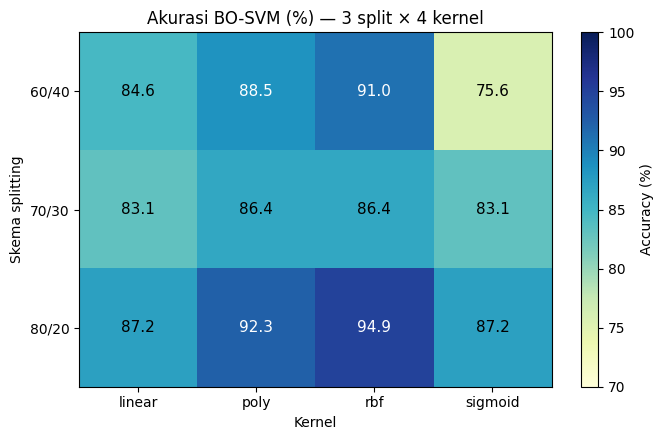

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
data = acc_bo.values.astype(float)
im = ax.imshow(data, cmap="YlGnBu", vmin=70, vmax=100)
ax.set_xticks(range(len(KERNELS))); ax.set_xticklabels(KERNELS)
ax.set_yticks(range(len(SPLITS))); ax.set_yticklabels(list(SPLITS))
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center",
                color="white" if data[i,j] > 88 else "black", fontsize=11)
ax.set_xlabel("Kernel"); ax.set_ylabel("Skema splitting")
ax.set_title("Akurasi BO-SVM (%) — 3 split × 4 kernel")
plt.colorbar(im, fraction=0.046, label="Accuracy (%)")
plt.tight_layout(); plt.show()

## 4. Kombinasi Terbaik

In [8]:
best_sl = acc_bo.max(axis=1).idxmax()
best_k  = acc_bo.loc[best_sl].idxmax()
best = store[(best_sl, best_k)]
print(f"Kombinasi terbaik: split {best_sl} + kernel '{best_k}'")
print(f"  Accuracy = {best['acc']:.1f}%  F1 = {best['f1']:.1f}%  "
      f"Recall = {best['recall']:.1f}%  Precision = {best['prec']:.1f}%")
print(f"  Hyperparameter: C = {best['C']:.3g}, gamma = {best['gamma']:.3g}")
print(f"  Confusion [TN,FP,FN,TP] = {best['cm'].ravel().tolist()}")

Kombinasi terbaik: split 80/20 + kernel 'rbf'


  Accuracy = 94.9%  F1 = 95.2%  Recall = 94.9%  Precision = 94.7%
  Hyperparameter: C = 100, gamma = 10
  Confusion [TN,FP,FN,TP] = [8, 2, 0, 29]


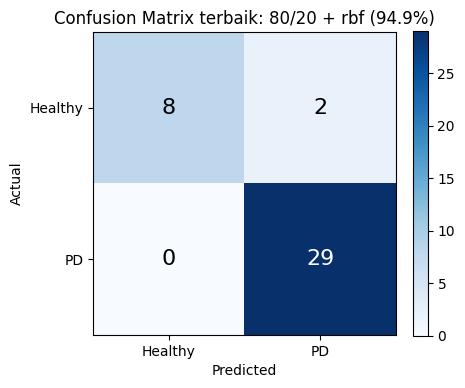

In [9]:
cm = best['cm']
plt.figure(figsize=(4.6, 4))
plt.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=16,
                 color="white" if cm[i,j] > cm.max()/2 else "black")
plt.xticks([0,1], ["Healthy","PD"]); plt.yticks([0,1], ["Healthy","PD"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix terbaik: {best_sl} + {best_k} ({best['acc']:.1f}%)")
plt.colorbar(fraction=0.046); plt.tight_layout(); plt.show()

## 5. Kurva ROC & Konvergensi BO (kombinasi terbaik)

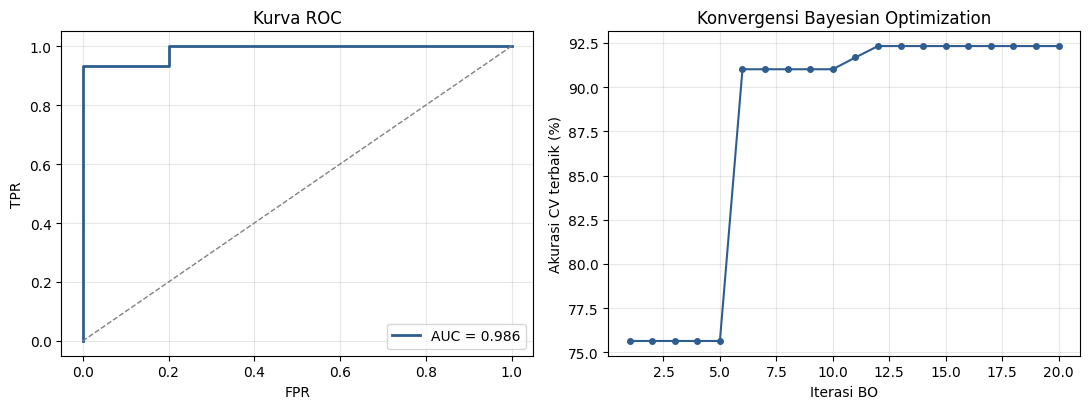

AUC = 0.986


In [10]:
# ROC -- refit dengan probability=True
svm_best = SVC(kernel=best_k, C=best['C'], gamma=best['gamma'],
               probability=True, random_state=RANDOM_STATE).fit(best['Xtr'], best['ytr'])
y_score = svm_best.predict_proba(best['Xte'])[:, 1]
fpr, tpr, _ = roc_curve(best['yte'], y_score); roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(fpr, tpr, color="#2e5d8f", lw=2, label=f"AUC = {roc_auc:.3f}")
ax[0].plot([0,1],[0,1], "--", color="gray", lw=1)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("Kurva ROC")
ax[0].legend(loc="lower right"); ax[0].grid(alpha=0.3)

sc = np.array(best['bo'].cv_results_["mean_test_score"])
ax[1].plot(range(1, len(sc)+1), np.maximum.accumulate(sc)*100, "-o", color="#2e5d8f", ms=4)
ax[1].set_xlabel("Iterasi BO"); ax[1].set_ylabel("Akurasi CV terbaik (%)")
ax[1].set_title("Konvergensi Bayesian Optimization"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"AUC = {roc_auc:.3f}")

## 6. Stabilitas tiap split (multi-seed, kernel RBF)
Karena dataset kecil, satu split bisa menyesatkan. Tiap rasio diuji pada 8 seed untuk melihat rata-rata & sebaran.

In [11]:
stab = {}
for sl, ts in SPLITS.items():
    accs = []
    for s in range(8):
        Xtr, Xte, ytr, yte = train_test_split(X_norm, y, test_size=ts, random_state=s, stratify=y)
        cv = StratifiedKFold(3, shuffle=True, random_state=s)
        bo = BayesSearchCV(SVC(kernel="rbf", random_state=s), space_cg,
                           n_iter=10, cv=cv, scoring="accuracy", random_state=s, n_jobs=-1)
        bo.fit(Xtr, ytr)
        accs.append(accuracy_score(yte, bo.best_estimator_.predict(Xte))*100)
    accs = np.array(accs)
    stab[sl] = [accs.mean(), accs.std(), accs.min(), accs.max()]
df_stab = pd.DataFrame(stab, index=["Mean","Std","Min","Max"]).T.round(1)
print("Stabilitas akurasi RBF-BO (8 seed):")
df_stab

Stabilitas akurasi RBF-BO (8 seed):


,Mean,Std,Min,Max
60/40,89.9,4.7,78.2,94.9
70/30,92.8,3.8,88.1,98.3
80/20,92.3,5.0,84.6,97.4


## 7. Rekomendasi & Kesimpulan

**Hasil grid (3 split × 4 kernel):**
- Kernel **RBF konsisten terbaik** di semua skema split — sesuai kesimpulan paper. Kernel `sigmoid` paling lemah.
- Akurasi cenderung **naik saat data latih bertambah** (60/40 → 80/20).

**Rekomendasi skema splitting:**
- Hindari **60/40** untuk dataset sekecil ini: data latih paling sedikit (117) sehingga akurasi RBF paling tidak stabil (std terbesar, lihat Bagian 6).
- Pilih **80/20 atau 70/30** dengan `stratify=y` — lebih banyak data latih, hasil lebih stabil dan akurat.
- Rekomendasi terkuat: laporkan **Stratified K-Fold Cross-Validation** (5- atau 10-fold) sebagai metrik utama; split tunggal cukup untuk ilustrasi, CV untuk klaim.

**Kombinasi terbaik keseluruhan:** lihat Bagian 4 (umumnya **RBF + 80/20**).

**Catatan kritis:** dataset kecil (195 rekaman dari 31 orang) dan tidak seimbang (75% PD). Untuk klaim lebih kuat, gunakan cross-validation dan pemisahan data per-subjek agar tidak ada kebocoran antar rekaman orang yang sama.